# 02 · Exploratory analysis: the stylised facts of volatility

Volatility models rely on a handful of empirical regularities ("stylised facts"). This notebook checks each of them on the cleaned data (`prices_clean`) for 50 European stocks and 9 indices, and states what it implies for the models built in the next steps.

| # | Stylised fact | Why it matters for forecasting |
|---|---|---|
| 1 | Returns have fat tails | Extreme days are far more frequent than a normal distribution predicts |
| 2 | Volatility clusters | Today's volatility predicts tomorrow's: the problem is forecastable |
| 3 | Volatility changes regime | Models must be evaluated in both calm and crisis periods |
| 4 | Falls raise volatility more than rises | Negative returns deserve their own feature (leverage effect) |
| 5 | Volatility is right-skewed | Model the logarithm of volatility |
| 6 | Markets move together | One model can learn from all stocks; the VIX carries information |
| 7 | Sectors differ in level | The model needs to know what it is forecasting |

In [1]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

from src.db import get_engine
from src.features.returns import TRADING_DAYS, add_log_returns, add_rolling_volatility, load_clean_prices
from src.viz import AQUA, BLUE, BLUE_LIGHT, GRID, INK, INK_2, MUTED, ORANGE, save, set_style, shade_crises

set_style()
engine = get_engine()
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:,.2f}".format)

## Data

Daily log returns are computed from the split-adjusted close. Volatility is measured here by the **21-day rolling standard deviation of returns**, annualised and in percent (better estimators based on the daily high-low range come in Step 4).

In [2]:
prices = load_clean_prices(engine)
df = add_rolling_volatility(add_log_returns(prices), window=21)

stocks = df[df["asset_type"] == "stock"]
indices = df[df["asset_type"] == "index"]
vix = df[df["ticker"] == "^VIX"].set_index("date")["close"]

print(f"{len(df):,} rows | {stocks['ticker'].nunique()} stocks, {indices['ticker'].nunique()} indices"
      f" | {df['date'].min():%Y-%m-%d} to {df['date'].max():%Y-%m-%d}")
print(f"Returns set to NaN because of a gap in the source data: {int(df['ret'].isna().sum() - df['ticker'].nunique())}")

395,548 rows | 50 stocks, 9 indices | 2000-01-03 to 2026-09-30
Returns set to NaN because of a gap in the source data: 17


## 1. Returns have fat tails

Each stock's returns are standardised (mean 0, standard deviation 1) and pooled. If returns were normally distributed, a move beyond 5 standard deviations would happen about once every 7,000 years per stock.

In [3]:
z = stocks.groupby("ticker")["ret"].transform(lambda r: (r - r.mean()) / r.std()).dropna()

from math import erfc, sqrt
tails = pd.DataFrame({
    "threshold": ["> 3 std", "> 4 std", "> 5 std"],
    "observed share of days": [(z.abs() > k).mean() for k in (3, 4, 5)],
    "normal distribution": [erfc(k / sqrt(2)) for k in (3, 4, 5)],
})
tails["times more frequent"] = tails["observed share of days"] / tails["normal distribution"]
print(f"Excess kurtosis of pooled standardised returns: {z.kurt():.1f} (normal distribution: 0)")
tails.style.format({"observed share of days": "{:.3%}", "normal distribution": "{:.5%}", "times more frequent": "{:,.0f}x"})

Excess kurtosis of pooled standardised returns: 14.7 (normal distribution: 0)


,threshold,observed share of days,normal distribution,times more frequent
0,> 3 std,1.552%,0.26998%,6x
1,> 4 std,0.597%,0.00633%,94x
2,> 5 std,0.271%,0.00006%,"4,725x"


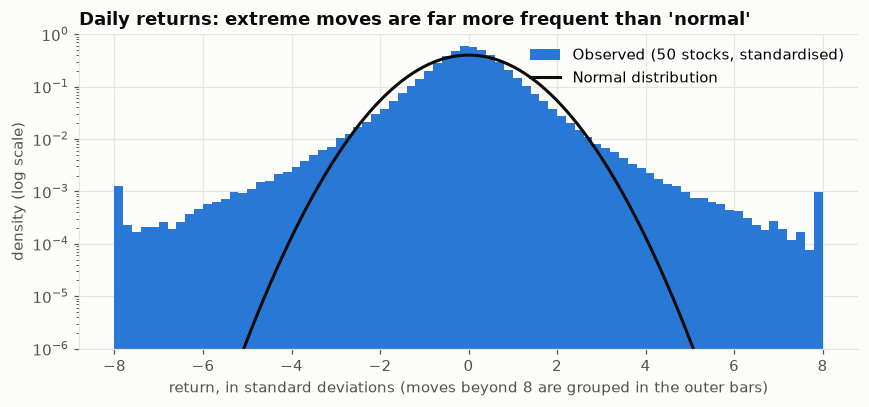

In [4]:
bins = np.linspace(-8, 8, 81)
x = np.linspace(-8, 8, 400)
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(z.clip(-8, 8), bins=bins, density=True, color=BLUE, label="Observed (50 stocks, standardised)")
ax.plot(x, np.exp(-x**2 / 2) / np.sqrt(2 * np.pi), color=INK, lw=2, label="Normal distribution")
ax.set_yscale("log")
ax.set_ylim(1e-6, 1)
ax.set_title("Daily returns: extreme moves are far more frequent than 'normal'")
ax.set_xlabel("return, in standard deviations (moves beyond 8 are grouped in the outer bars)")
ax.set_ylabel("density (log scale)")
ax.legend(loc="upper right")
fig.tight_layout()
save(fig, "03_fat_tails")
plt.show()

**Implication.** Squared-error losses are dominated by a few extreme days, and Value-at-Risk based on a normal distribution underestimates risk. Step 5 therefore uses QLIKE alongside MSE, and Step 10 backtests VaR explicitly.

## 2. Volatility clusters

Returns themselves are almost uncorrelated from one day to the next (the direction of the market cannot be predicted from yesterday's return), but their **size** is strongly autocorrelated: large moves follow large moves. This is the property that makes volatility forecastable.

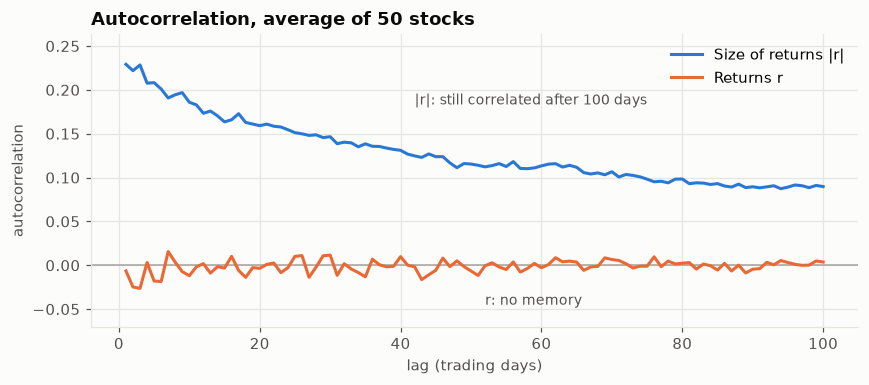

Autocorrelation at lag 1 / 5 / 22 / 100 days
  returns:   -0.006 / -0.018 / +0.003 / +0.004
  |returns|: +0.229 / +0.208 / +0.159 / +0.090


In [5]:
def acf(series: pd.Series, nlags: int) -> np.ndarray:
    """Autocorrelation for lags 1..nlags (NaN dropped)."""
    x = series.dropna().to_numpy()
    x = x - x.mean()
    denom = np.dot(x, x)
    return np.array([np.dot(x[k:], x[:-k]) / denom for k in range(1, nlags + 1)])

NLAGS = 100
acf_ret = np.mean([acf(g["ret"], NLAGS) for _, g in stocks.groupby("ticker")], axis=0)
acf_abs = np.mean([acf(g["ret"].abs(), NLAGS) for _, g in stocks.groupby("ticker")], axis=0)
lags = np.arange(1, NLAGS + 1)

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.axhline(0, color=MUTED, lw=1)
ax.plot(lags, acf_abs, color=BLUE, lw=2, label="Size of returns |r|")
ax.plot(lags, acf_ret, color=ORANGE, lw=2, label="Returns r")
ax.annotate("|r|: still correlated after 100 days", (60, acf_abs[59]), xytext=(42, acf_abs[59] + 0.07), color=INK_2, fontsize=9)
ax.annotate("r: no memory", (60, 0), xytext=(52, -0.045), color=INK_2, fontsize=9)
ax.set_title("Autocorrelation, average of 50 stocks")
ax.set_xlabel("lag (trading days)")
ax.set_ylabel("autocorrelation")
ax.set_ylim(-0.07, max(acf_abs) * 1.15)
ax.legend(loc="upper right")
fig.tight_layout()
save(fig, "03_volatility_clustering")
plt.show()

print(f"Autocorrelation at lag 1 / 5 / 22 / 100 days")
print(f"  returns:   {acf_ret[0]:+.3f} / {acf_ret[4]:+.3f} / {acf_ret[21]:+.3f} / {acf_ret[99]:+.3f}")
print(f"  |returns|: {acf_abs[0]:+.3f} / {acf_abs[4]:+.3f} / {acf_abs[21]:+.3f} / {acf_abs[99]:+.3f}")

**Implication.** The autocorrelation of |returns| decays very slowly (*long memory*): yesterday, last week and last month all carry information. This is exactly the structure of the HAR model (daily, weekly and monthly volatility), which will be the benchmark to beat.

## 3. Volatility changes regime

The line is the volatility of the **median** stock; the band covers the middle half of the 50 stocks.

107 dates with fewer than 30 stocks trading are excluded from this chart


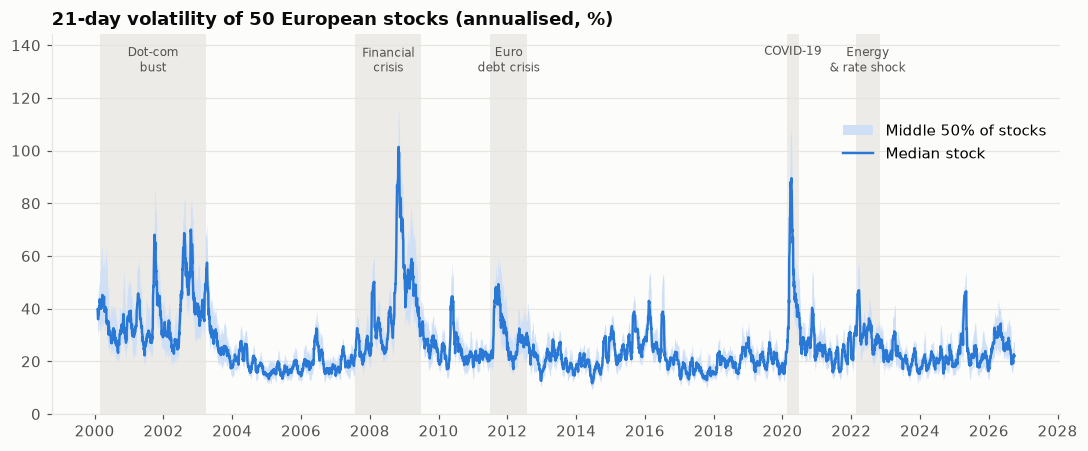

Median-stock volatility: lowest 12%, typical 23%, highest 101% on 03 Nov 2008


In [6]:
# Keep dates on which at least 30 of the 50 stocks traded: on local holidays only a
# few exchanges are open and a "median stock" computed on a handful of names is misleading.
MIN_STOCKS = 30
n_traded = stocks.groupby("date")["vol_21d"].count()
full_days = stocks[stocks["date"].isin(n_traded[n_traded >= MIN_STOCKS].index)]
cross = full_days.groupby("date")["vol_21d"].quantile([0.25, 0.5, 0.75]).unstack().dropna()
cross.columns = ["q25", "median", "q75"]
print(f"{(n_traded < MIN_STOCKS).sum()} dates with fewer than {MIN_STOCKS} stocks trading are excluded from this chart")

fig, ax = plt.subplots(figsize=(10, 4.2))
ax.fill_between(cross.index, cross["q25"], cross["q75"], color=BLUE_LIGHT, lw=0, label="Middle 50% of stocks")
ax.plot(cross.index, cross["median"], color=BLUE, lw=1.6, label="Median stock")
shade_crises(ax)
ax.set_title("21-day volatility of 50 European stocks (annualised, %)")
ax.set_ylim(0, cross["q75"].max() * 1.25)
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.grid(axis="x", visible=False)
ax.legend(loc="upper right", bbox_to_anchor=(1, 0.8))
fig.tight_layout()
save(fig, "03_volatility_regimes")
plt.show()

peak = cross["median"].idxmax()
print(f"Median-stock volatility: lowest {cross['median'].min():.0f}%, typical {cross['median'].median():.0f}%, "
      f"highest {cross['median'].max():.0f}% on {peak:%d %b %Y}")

In [7]:
# Average volatility of the median stock inside and outside the shaded periods
from src.viz import CRISES
in_crisis = pd.Series(False, index=cross.index)
rows = []
for name, (start, end) in CRISES.items():
    mask = (cross.index >= start) & (cross.index <= end)
    in_crisis |= mask
    rows.append({"period": name, "from": start[:7], "to": end[:7], "mean median-stock vol (%)": cross.loc[mask, "median"].mean(),
                 "peak (%)": cross.loc[mask, "median"].max()})
rows.append({"period": "All other days", "from": "", "to": "", "mean median-stock vol (%)": cross.loc[~in_crisis, "median"].mean(),
             "peak (%)": cross.loc[~in_crisis, "median"].max()})
pd.DataFrame(rows).set_index("period")

,from,to,mean median-stock vol (%),peak (%)
period,,,,
Dot-com bust,2000-03,2003-03,37.18,69.94
Financial crisis,2007-08,2009-06,40.44,101.42
Euro debt crisis,2011-07,2012-07,30.02,49.33
COVID-19,2020-02,2020-06,50.56,89.52
Energy & rate shock,2022-02,2022-10,31.51,46.91
All other days,,,22.12,57.46


**Implication.** Volatility moves between calm regimes and short, violent crises, then reverts to its long-run level (*mean reversion*). A model that only looks good on average may fail exactly when it matters, so Step 9 reports results separately for calm and stress periods.

## 4. Falls raise volatility more than rises (leverage effect)

For every stock and day, today's return is put in a bucket by size and direction; the bars show the average volatility realised over the **next 5 trading days**.

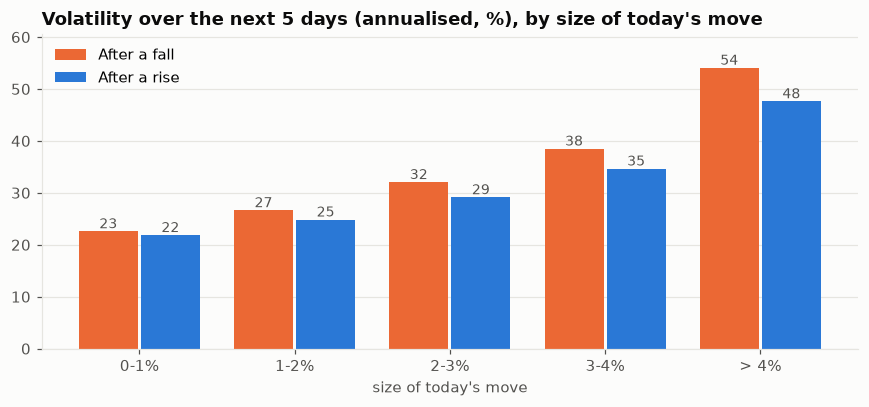

direction,After a fall,After a rise,difference
size,,,
0-1%,22.58,21.86,0.73
1-2%,26.64,24.84,1.80
2-3%,32.06,29.14,2.92
3-4%,38.50,34.65,3.85
> 4%,54.07,47.61,6.46


In [8]:
def forward_volatility(returns: pd.Series, horizon: int = 5) -> pd.Series:
    """Annualised volatility (%) realised over the NEXT `horizon` days (excluding today)."""
    future_var = (returns**2)[::-1].rolling(horizon, min_periods=horizon).mean()[::-1].shift(-1)
    return np.sqrt(future_var * TRADING_DAYS) * 100

s = stocks[["ticker", "date", "ret"]].copy()
s["fwd_vol_5d"] = s.groupby("ticker")["ret"].transform(forward_volatility)
s = s.dropna()
s["size"] = pd.cut(s["ret"].abs() * 100, [0, 1, 2, 3, 4, np.inf], labels=["0-1%", "1-2%", "2-3%", "3-4%", "> 4%"])
s["direction"] = np.where(s["ret"] < 0, "After a fall", "After a rise")
lev = s.pivot_table(index="size", columns="direction", values="fwd_vol_5d", aggfunc="mean", observed=True)

xpos = np.arange(len(lev))
fig, ax = plt.subplots(figsize=(8, 3.8))
ax.bar(xpos - 0.2, lev["After a fall"], width=0.38, color=ORANGE, label="After a fall")
ax.bar(xpos + 0.2, lev["After a rise"], width=0.38, color=BLUE, label="After a rise")
for i, (fall, rise) in enumerate(zip(lev["After a fall"], lev["After a rise"])):
    ax.text(i - 0.2, fall + 0.6, f"{fall:.0f}", ha="center", color=INK_2, fontsize=9)
    ax.text(i + 0.2, rise + 0.6, f"{rise:.0f}", ha="center", color=INK_2, fontsize=9)
ax.set_xticks(xpos, lev.index)
ax.set_ylim(0, lev.max().max() * 1.12)
ax.set_title("Volatility over the next 5 days (annualised, %), by size of today's move")
ax.set_xlabel("size of today's move")
ax.grid(axis="x", visible=False)
ax.legend(loc="upper left")
fig.tight_layout()
save(fig, "03_leverage_effect")
plt.show()

lev.assign(difference=lev["After a fall"] - lev["After a rise"])

**Implication.** Two things are visible: bigger moves today mean higher volatility tomorrow (clustering again), and for a move of the same size a **fall** is followed by more volatility than a rise. Step 4 therefore adds negative returns as separate features, and Step 6 includes GJR-GARCH, the GARCH variant designed for this asymmetry.

## 5. Volatility is right-skewed, its logarithm is not

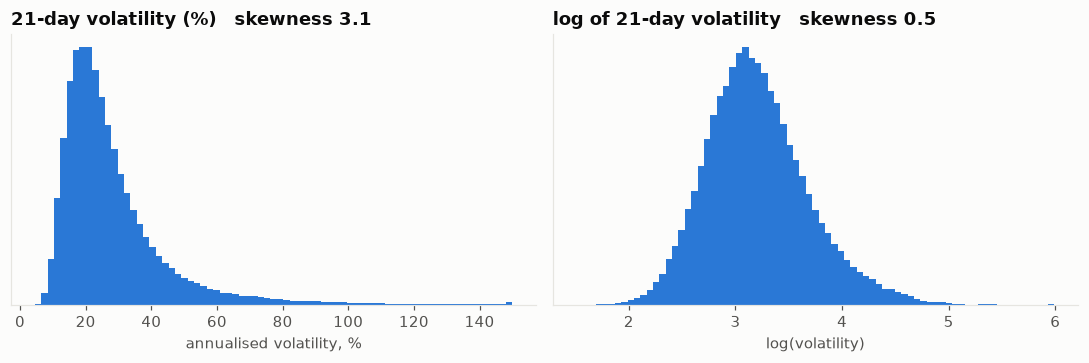

In [9]:
vol = stocks["vol_21d"].dropna()
vol = vol[vol > 0]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].hist(vol.clip(upper=150), bins=75, color=BLUE)
axes[0].set_title(f"21-day volatility (%)   skewness {vol.skew():.1f}")
axes[0].set_xlabel("annualised volatility, %")
axes[1].hist(np.log(vol), bins=75, color=BLUE)
axes[1].set_title(f"log of 21-day volatility   skewness {np.log(vol).skew():.1f}")
axes[1].set_xlabel("log(volatility)")
for a in axes:
    a.set_yticks([])
    a.grid(visible=False)
fig.tight_layout()
save(fig, "03_log_volatility")
plt.show()

**Implication.** In levels, a few crisis observations dominate any squared-error fit. The logarithm is close to symmetric, so the models will forecast **log volatility** (and convert back for evaluation).

## 6. Markets move together

Correlation between the 21-day volatilities of the nine indices (log scale, common dates).

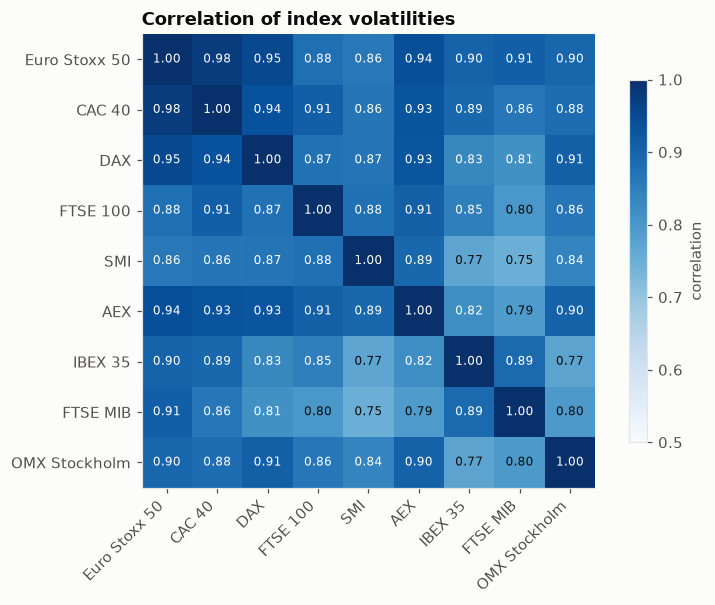

Average pairwise correlation: 0.87 (min 0.75, max 0.98)


In [10]:
short = {"^STOXX50E": "Euro Stoxx 50", "^FCHI": "CAC 40", "^GDAXI": "DAX", "^FTSE": "FTSE 100", "^SSMI": "SMI",
         "^AEX": "AEX", "^IBEX": "IBEX 35", "FTSEMIB.MI": "FTSE MIB", "^OMX": "OMX Stockholm"}
ivol = np.log(indices.pivot(index="date", columns="ticker", values="vol_21d")[list(short)].rename(columns=short))
corr = ivol.corr()

fig, ax = plt.subplots(figsize=(7.4, 5.6))
im = ax.imshow(corr, cmap="Blues", vmin=0.5, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.index)
for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=8, color="white" if v > 0.8 else INK)
ax.set_title("Correlation of index volatilities")
ax.grid(visible=False)
fig.colorbar(im, ax=ax, shrink=0.8, label="correlation")
fig.tight_layout()
save(fig, "03_volatility_correlation")
plt.show()

off_diag = corr.where(~np.eye(len(corr), dtype=bool)).stack()
print(f"Average pairwise correlation: {off_diag.mean():.2f} (min {off_diag.min():.2f}, max {off_diag.max():.2f})")

Does the **VIX** add information? For each index, the table compares how well two signals known at the close of day *t-1* line up with the volatility realised over the following 5 days: the index's own past 21-day volatility, and the VIX (lagged one day, because it closes after European markets).

In [11]:
rows = []
for ticker, name in short.items():
    g = indices[indices["ticker"] == ticker].set_index("date")
    target = np.log(forward_volatility(g["ret"], 5).replace(0, np.nan))        # days t+1 .. t+5
    past_vol = np.log(g["vol_21d"])                                             # known at close of t
    vix_lag = np.log(vix.reindex(g.index, method="ffill").shift(1))             # VIX close of t-1
    both = pd.concat([target, past_vol, vix_lag], axis=1, keys=["target", "past_vol", "vix"]).dropna()
    rows.append({"index": name, "own past 21-day vol": both["target"].corr(both["past_vol"]),
                 "VIX (lagged 1 day)": both["target"].corr(both["vix"]), "days": len(both)})
vix_table = pd.DataFrame(rows).set_index("index")
vix_table

,own past 21-day vol,VIX (lagged 1 day),days
index,,,
Euro Stoxx 50,0.55,0.57,4858
CAC 40,0.61,0.62,6810
DAX,0.62,0.61,6766
FTSE 100,0.60,0.63,6730
SMI,0.56,0.56,6683
AEX,0.64,0.65,6811
IBEX 35,0.60,0.57,6777
FTSE MIB,0.62,0.54,6763
OMX Stockholm,0.55,0.59,4450


**Implication.** European volatilities are highly correlated, which supports training **one pooled model** on all series (more data for the neural networks) and testing whether it generalises to unseen markets (Step 9). A lagged US indicator is about as informative as the index's own history, so the VIX is kept as a feature and its contribution is measured by ablation.

## 7. Sectors differ in level

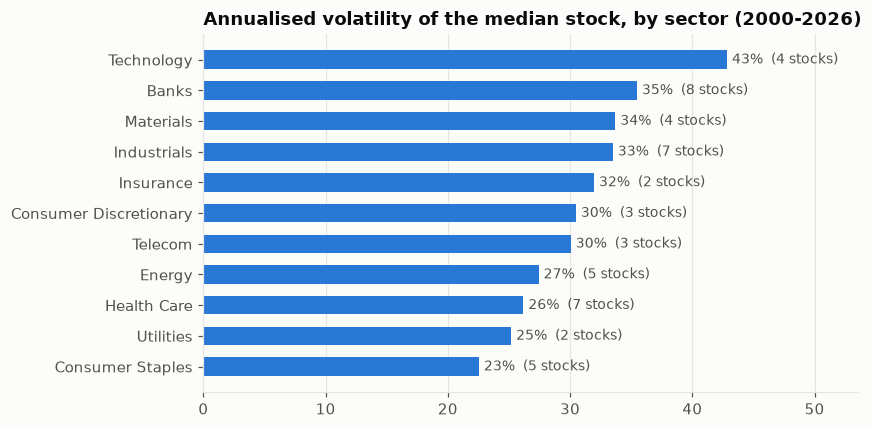

Least and most volatile stocks over the full sample:


,name,sector,country,vol
29,Nestle,Consumer Staples,Switzerland,18.64
31,Novartis,Health Care,Switzerland,20.28
2,Ahold Delhaize,Consumer Staples,Netherlands,20.90
46,Unilever,Consumer Staples,United Kingdom,22.55
36,Roche,Health Care,Switzerland,23.30
27,ArcelorMittal,Materials,Luxembourg,45.75
30,Nokia,Technology,Finland,43.82
6,ASML,Technology,Netherlands,43.04
18,Ericsson,Technology,Sweden,42.65
21,ING Group,Banks,Netherlands,42.59


In [12]:
per_stock = (stocks.groupby(["ticker", "name", "sector", "country"])["ret"].std() * np.sqrt(TRADING_DAYS) * 100).rename("vol").reset_index()
by_sector = per_stock.groupby("sector")["vol"].agg(["median", "count"]).sort_values("median")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(by_sector.index, by_sector["median"], color=BLUE, height=0.6)
for y, (v, n) in enumerate(zip(by_sector["median"], by_sector["count"])):
    ax.text(v + 0.4, y, f"{v:.0f}%  ({n} stocks)", va="center", color=INK_2, fontsize=9)
ax.set_title("Annualised volatility of the median stock, by sector (2000-2026)")
ax.set_xlim(0, by_sector["median"].max() * 1.25)
ax.grid(axis="y", visible=False)
fig.tight_layout()
save(fig, "03_volatility_by_sector")
plt.show()

print("Least and most volatile stocks over the full sample:")
pd.concat([per_stock.nsmallest(5, "vol"), per_stock.nlargest(5, "vol")])[["name", "sector", "country", "vol"]]

**Implication.** Defensive sectors (consumer staples, utilities, health care) are structurally calmer than banks, industrials and technology. A pooled model must be able to tell series apart: either by scaling each series by its own long-run volatility, or by giving the model sector and country as features (Step 4).

## Summary

| Finding | Evidence | Consequence for the project |
|---|---|---|
| Fat tails | Moves beyond 5 standard deviations are thousands of times more frequent than under a normal distribution | Robust loss (QLIKE); VaR backtesting |
| Clustering and long memory | Autocorrelation of \|r\| stays positive for 100+ days; returns have none | HAR (day / week / month) as the benchmark |
| Regimes | Median-stock volatility ranges from about 10% to over 100% | Evaluate separately in calm and crisis periods |
| Leverage effect | A fall is followed by more volatility than a rise of the same size | Negative-return features; GJR-GARCH |
| Skewness | Volatility is right-skewed, log volatility is roughly symmetric | Forecast log volatility |
| Co-movement | Index volatilities are strongly correlated; lagged VIX is informative | Pooled model; VIX feature with ablation |
| Sector levels | Technology and banks are far more volatile than staples and utilities | Per-series scaling or sector features |